R2 Score: 0.5542632452871117
MSE: 3418946311.180807
Predicted Price: 229877.66599078485


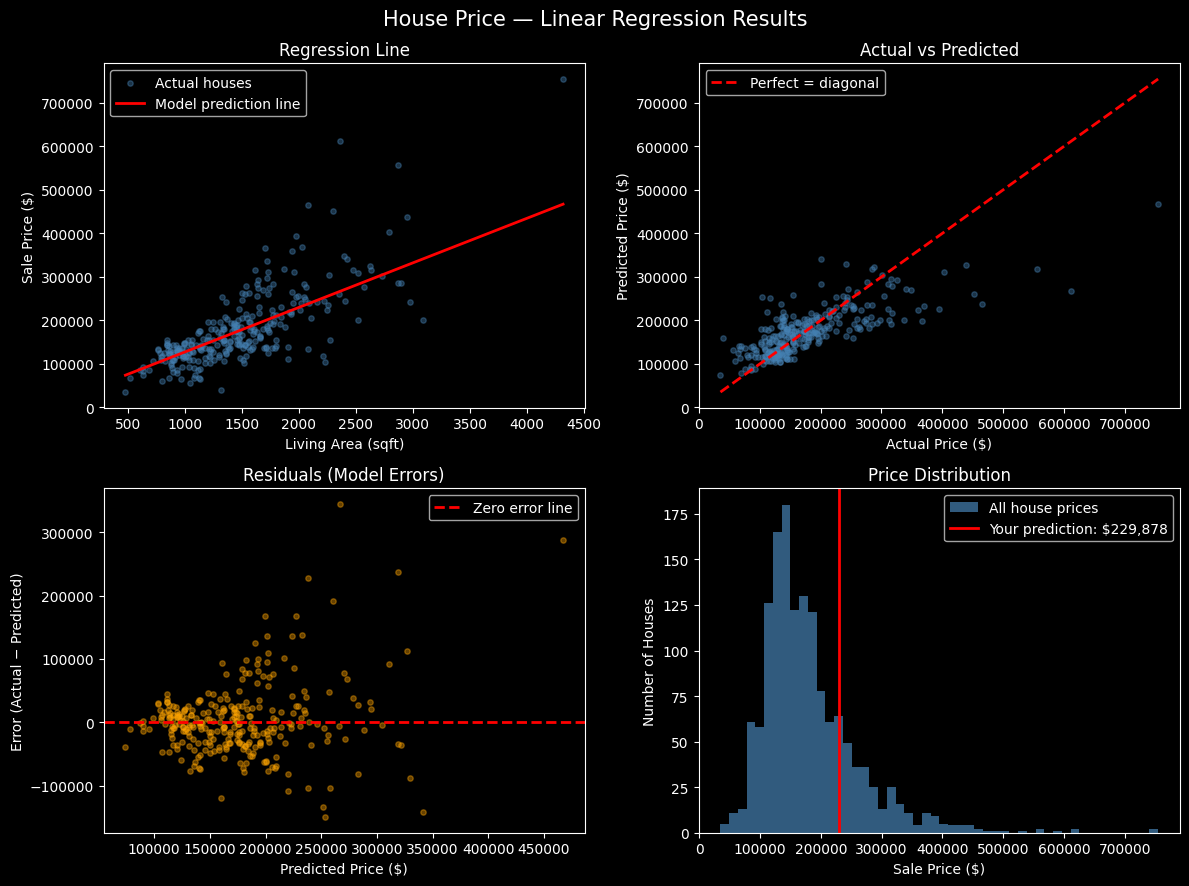


Chart saved as house_price_charts.png


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt  # NEW: for making charts
import numpy as np               # NEW: for math helpers

# ── Your original code (unchanged) ──────────────────────────
data = pd.read_csv('train.csv')

X = data[['GrLivArea']]
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

new_house = pd.DataFrame({'GrLivArea': [2000]})
predicted_price = model.predict(new_house)
print("Predicted Price:", predicted_price[0])

# ── NEW: 4 Visualizations ────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('House Price — Linear Regression Results', fontsize=15)

# ── Chart 1: Regression Line ─────────────────────────────────
# Shows the straight line your model learned
ax = axes[0, 0]
ax.scatter(X_test, y_test, alpha=0.4, color='steelblue', s=15, label='Actual houses')
ax.plot(X_test.sort_values('GrLivArea'),
        model.predict(X_test.sort_values('GrLivArea')),
        color='red', linewidth=2, label='Model prediction line')
ax.set_xlabel('Living Area (sqft)')
ax.set_ylabel('Sale Price ($)')
ax.set_title('Regression Line')
ax.legend()

# ── Chart 2: Actual vs Predicted ─────────────────────────────
# Perfect model = all dots on the diagonal line
ax = axes[0, 1]
ax.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
# Draw the "perfect prediction" diagonal
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect = diagonal')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title('Actual vs Predicted')
ax.legend()

# ── Chart 3: Residuals ────────────────────────────────────────
# Residual = actual - predicted (your model's mistakes)
# Good model = dots randomly scattered around 0
ax = axes[1, 0]
residuals = y_test - y_pred
ax.scatter(y_pred, residuals, alpha=0.4, color='orange', s=15)
ax.axhline(y=0, color='red', linewidth=2, linestyle='--', label='Zero error line')
ax.set_xlabel('Predicted Price ($)')
ax.set_ylabel('Error (Actual − Predicted)')
ax.set_title('Residuals (Model Errors)')
ax.legend()

# ── Chart 4: Price Distribution ───────────────────────────────
# Shows where house prices cluster, and where your prediction lands
ax = axes[1, 1]
ax.hist(y, bins=50, color='steelblue', alpha=0.7, label='All house prices')
ax.axvline(x=predicted_price[0], color='red', linewidth=2,
           label=f'Your prediction: ${predicted_price[0]:,.0f}')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Number of Houses')
ax.set_title('Price Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('house_price_charts.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nChart saved as house_price_charts.png")